In [1]:
import sys
sys.path.append('/Users/mariana/Documents/projects/Huawei/survan')
# sys.path.append('/home/mvargas/code/Huawei/survan')

from deep_lambda_cox import DeepLambdaSA
from lambda_cox import LambdaSA
from baseline_cox import SA

from utils import concordance_index, unroll_time, get_single_task_dataset, kaplan_meier, pad_to, get_single_target_and_mask
import yaml
import jax
import jax.numpy as jnp
import numpy as np
import haiku as hk
import matplotlib.pyplot as plt

In [7]:
config_path = '../configs/config_tasks.yaml'
config = yaml.load(open(config_path, 'r'), Loader=yaml.FullLoader)

In [8]:
config['dataset_kwargs']['task_id'] = 5
task_id = config['dataset_kwargs']['task_id']
task_id

5

In [9]:
%%time

#Baseline SA with and wo landmarking
num_exps = 5
sizes = [.2]

ibs_is = np.zeros((num_exps, len(sizes)))
ibs_lm = np.zeros((num_exps, len(sizes)))

ci_is = np.zeros((num_exps, len(sizes)))
ci_lm = np.zeros((num_exps, len(sizes)))

for fold in range(num_exps):
    for i, size in enumerate(sizes):
        
        print(".", end="")
        
        # Initial state.
        config['landmark'] = False
        model = SA(config, seed=fold)
        
        train_gen, test_gen = model.get_train_test(test_size=size)
        seqs = test_gen.X
        ts = test_gen.ts
        cs = test_gen.cs
        
        _ = model.train(train_gen, test_gen)
        surv = model.survival_curve(seqs)
        ibs_is[fold, i] = model.integrated_brier_score(surv[:,0], ts, cs)
        scores = model.scores(seqs, q=0.0)
        ci_is[fold, i] = concordance_index(scores, ts, cs)

        # Landmarking.
        config['landmark'] = True
        model = SA(config, seed=fold)
        
        train_gen, test_gen = model.get_train_test(test_size=size)
        seqs = test_gen.X
        ts = test_gen.ts
        cs = test_gen.cs
        ms = test_gen.mask
        
        _ = model.train(train_gen, test_gen)
        surv = model.survival_curve(seqs)
        ibs_lm[fold, i] = model.integrated_brier_score(surv[:,0], ts, cs)
        scores = model.scores(seqs, q=0.0)
        ci_lm[fold, i] = concordance_index(scores, ts, cs)
        
    print()

.
.
.
.
.
CPU times: user 51min 24s, sys: 8min 4s, total: 59min 28s
Wall time: 2h 9min 2s


In [10]:
ci_lm

array([[0.97165717],
       [0.9652318 ],
       [0.9730242 ],
       [0.96939453],
       [0.9718651 ]])

In [11]:
%%time

num_exps = 5
sizes = [.2]
size = sizes[0]
tgt_lrs = [.1]

bs_0 = np.zeros((num_exps, len(tgt_lrs)))
bs_1 = np.zeros((num_exps, len(tgt_lrs)))

ci_0 = np.zeros((num_exps, len(tgt_lrs)))
ci_1 = np.zeros((num_exps, len(tgt_lrs)))

for fold in range(num_exps):
    for i, tgt_lr in enumerate(tgt_lrs):
        config['target_lr'] = tgt_lr
        
        print(".", end="")
        
        # Landmarking.
        config['lambda_'] = .9
        model = DeepLambdaSA(config, seed=fold)
        
        train_gen, test_gen = model.get_train_test(test_size=size)
        seqs = test_gen.X
        ts = test_gen.ts
        cs = test_gen.cs
        
        _ = model.train(train_gen)
        surv = model.survival_curve(seqs)
        bs_1[fold, i] = model.integrated_brier_score(surv[:,0], ts, cs)
        scores = model.scores(seqs, q=0.0)
        ci_1[fold, i] = concordance_index(scores, ts, cs)

        # TCSR.
        config['lambda_'] = 0.0
        model = DeepLambdaSA(config, seed=fold)
        
        train_gen, test_gen = model.get_train_test(test_size=size)
        seqs = test_gen.X
        ts = test_gen.ts
        cs = test_gen.cs
        
        _ = model.train(train_gen)
        surv = model.survival_curve(seqs)
        bs_0[fold, i] = model.integrated_brier_score(surv[:,0], ts, cs)
        # scores = model.scores(jnp.expand_dims(seqs[:,0], axis=1)).squeeze()
        scores = model.scores(seqs, q=0.0)
        ci_0[fold, i] = concordance_index(scores, ts, cs)
        
    print()

.
.
.
.
.
CPU times: user 1h 13min, sys: 12min 32s, total: 1h 25min 32s
Wall time: 2h 35min 16s


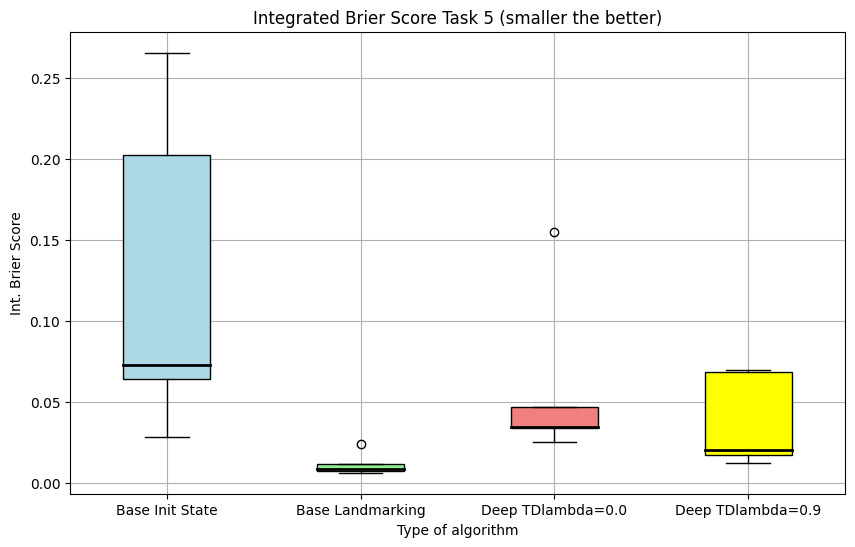

In [12]:
savefig = False

# Create a figure and axis
fig, ax = plt.subplots(figsize=(10, 6))


# Set the positions for the boxes
positions = [1, 2, 3, 4]

medianprops = dict(color='black', linewidth=2)

# Create the boxplots
bs_is = ibs_is.reshape(-1)
bs_lm = ibs_lm.reshape(-1)
bs_a9 = bs_1.reshape(-1)
bs_a0 = bs_0.reshape(-1)
boxplot = ax.boxplot([bs_is, bs_lm, bs_a0, bs_a9], medianprops=medianprops, positions=positions, patch_artist=True)

# Customize the appearance (colors, labels, etc.) as needed
ax.set_xticks(positions)
ax.set_xticklabels(['Base Init State', 'Base Landmarking', 'Deep TDlambda=0.0', 'Deep TDlambda=0.9'])
ax.set_xlabel("Type of algorithm")
ax.set_ylabel("Int. Brier Score")
ax.set_title("Integrated Brier Score Task {} (smaller the better)".format(task_id))
ax.grid()

# Optionally, fill the boxes with colors
colors = ['lightblue', 'lightgreen', 'lightcoral', 'yellow']
for patch, color in zip(boxplot['boxes'], colors):
    patch.set_facecolor(color)

# Save the figure as a PDF with tight layout
if savefig:
    plt.tight_layout()  # Ensures a tight layout
    plt.savefig("../../Figures/survan/runtime_pred/Int_brier_score_task_{}_transf.pdf".format(task_id), format="pdf")

plt.show()


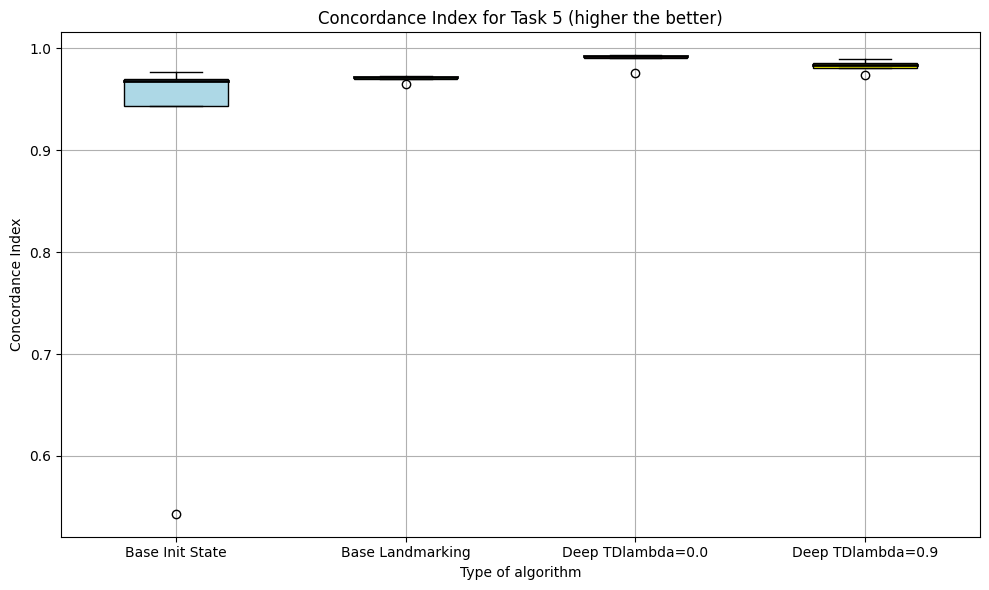

In [13]:


# Create a figure and axis
fig, ax = plt.subplots(figsize=(10, 6))


# Set the positions for the boxes
positions = [1, 2, 3, 4]

medianprops = dict(color='black', linewidth=2)

# Create the boxplots
ci_is = ci_is.reshape(-1)
ci_lm = ci_lm.reshape(-1)
ci_a9 = ci_1.reshape(-1)
ci_a0 = ci_0.reshape(-1)
boxplot = ax.boxplot([ci_is, ci_lm, ci_a0, ci_a9], medianprops=medianprops, positions=positions, patch_artist=True)

# Customize the appearance (colors, labels, etc.) as needed
ax.set_xticks(positions)
ax.set_xticklabels(['Base Init State', 'Base Landmarking', 'Deep TDlambda=0.0', 'Deep TDlambda=0.9'])
ax.set_xlabel("Type of algorithm")
ax.set_ylabel("Concordance Index")
ax.set_title("Concordance Index for Task {} (higher the better)".format(task_id))
ax.grid()

# Optionally, fill the boxes with colors
colors = ['lightblue', 'lightgreen', 'lightcoral', 'yellow']
for patch, color in zip(boxplot['boxes'], colors):
    patch.set_facecolor(color)

# Save the figure as a PDF with tight layout
if savefig:
    plt.tight_layout()  # Ensures a tight layout
    plt.savefig("../../Figures/Concordance_idx_task_{}_shallow.pdf".format(task_id), format="pdf")

plt.show()


In [57]:
config['target_lr'] = 0.1
config['num_epochs'] = 200
config['learning_rate'] = .01

In [59]:
%%time

num_exps = 5
sizes = [.2]
size = sizes[0]
lambdas = [0.0, 0.1, 0.5, 0.9, 1.0]

bs_0 = np.zeros((num_exps, len(lambdas)))
ci_0 = np.zeros((num_exps, len(lambdas)))

for fold in range(num_exps):
    for i, lambda_ in enumerate(lambdas):
        config['lambda_'] = lambda_
        print(".", end="")

        # TCSR.
        model = DeepLambdaSA(config, seed=fold)
        
        train_gen, test_gen = model.get_train_test(test_size=size)
        seqs = test_gen.X
        ts = test_gen.ts
        cs = test_gen.cs
        
        _ = model.train(train_gen)
        surv = model.survival_curve(seqs)
        bs_0[fold, i] = model.integrated_brier_score(surv[:,0], ts, cs)
        beta = model.state.params['cox_linear_model']['beta']
        scores = model.scores(jnp.expand_dims(seqs[:,0], axis=1)).squeeze()
        ci_0[fold, i] = concordance_index(scores, ts, cs)
        
    print()

.

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [02:03<00:00,  1.61it/s]


.

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [02:03<00:00,  1.62it/s]


.

...

.

100%|███████████████████████████████████████████████████████████████████████████████████████████| 200/200 [02:14<00:00,  1.49it/s]


.

100%|███████████████████████████████████████████████████████████████████████████████████████████| 200/200 [02:17<00:00,  1.46it/s]


CPU times: user 3h 3min 20s, sys: 11min 56s, total: 3h 15min 16s
Wall time: 53min 37s


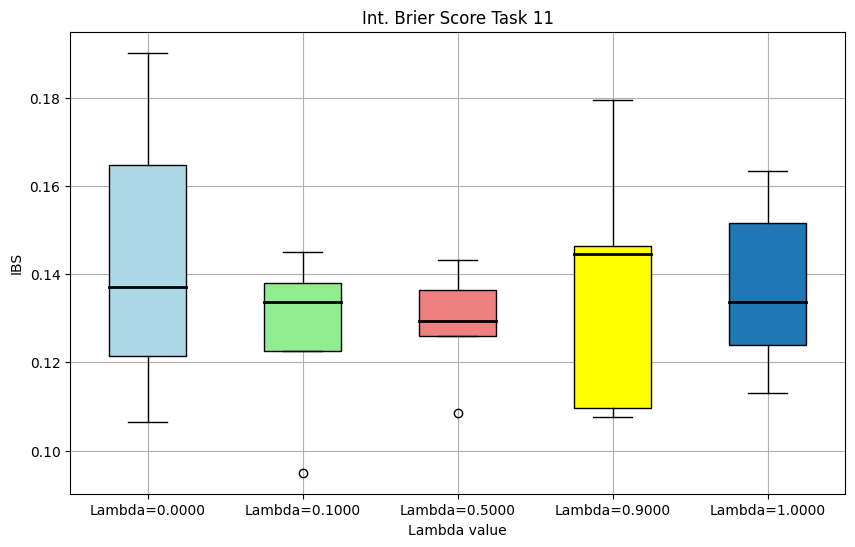

In [61]:


# Create a figure and axis
fig, ax = plt.subplots(figsize=(10, 6))


# Set the positions for the boxes
positions = [i+1 for i in range(num_exps)]
medianprops = dict(color='black', linewidth=2)

# Create the boxplots
boxplot = ax.boxplot([bs_0[i] for i in range(num_exps)], medianprops=medianprops, positions=positions, patch_artist=True)

# Customize the appearance (colors, labels, etc.) as needed
ax.set_xticks(positions)
ax.set_xticklabels([f'Lambda={lambda_:.4f}' for lambda_ in lambdas])
ax.set_xlabel("Lambda value")
ax.set_ylabel("IBS")
ax.set_title("Int. Brier Score Task {}".format(task_id))
ax.grid()

# Optionally, fill the boxes with colors
colors = ['lightblue', 'lightgreen', 'lightcoral', 'yellow']
for patch, color in zip(boxplot['boxes'], colors):
    patch.set_facecolor(color)

# Save the figure as a PDF with tight layout
# plt.tight_layout()  # Ensures a tight layout
# plt.savefig("../../Figures/Concordance_idx_task_{}.pdf".format(task_id), format="pdf")

plt.show()


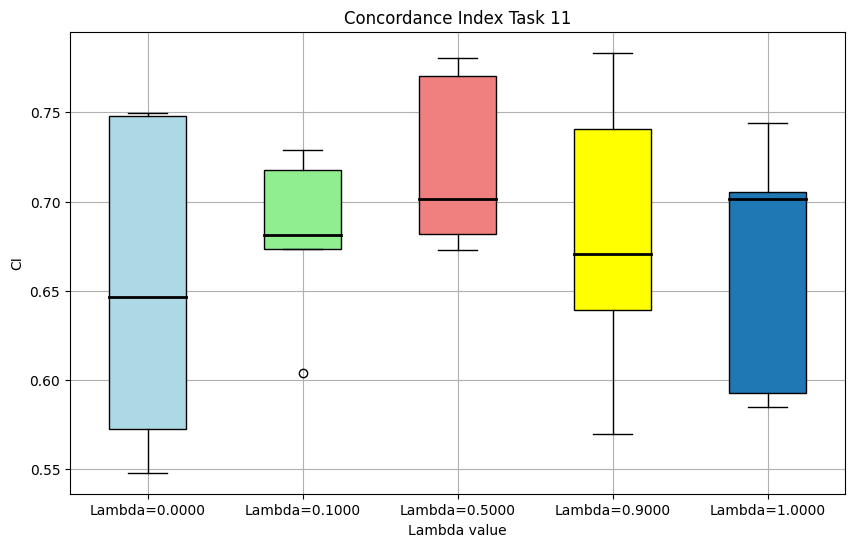

In [63]:


# Create a figure and axis
fig, ax = plt.subplots(figsize=(10, 6))


# Set the positions for the boxes
positions = [i+1 for i in range(num_exps)]
medianprops = dict(color='black', linewidth=2)

# Create the boxplots
boxplot = ax.boxplot([ci_0[i] for i in range(num_exps)], medianprops=medianprops, positions=positions, patch_artist=True)

# Customize the appearance (colors, labels, etc.) as needed
ax.set_xticks(positions)
ax.set_xticklabels([f'Lambda={lambda_:.4f}' for lambda_ in lambdas])
ax.set_xlabel("Lambda value")
ax.set_ylabel("CI")
ax.set_title("Concordance Index Task {}".format(task_id))
ax.grid()

# Optionally, fill the boxes with colors
colors = ['lightblue', 'lightgreen', 'lightcoral', 'yellow']
for patch, color in zip(boxplot['boxes'], colors):
    patch.set_facecolor(color)

# Save the figure as a PDF with tight layout
# plt.tight_layout()  # Ensures a tight layout
# plt.savefig("../../Figures/Concordance_idx_task_{}.pdf".format(task_id), format="pdf")

plt.show()


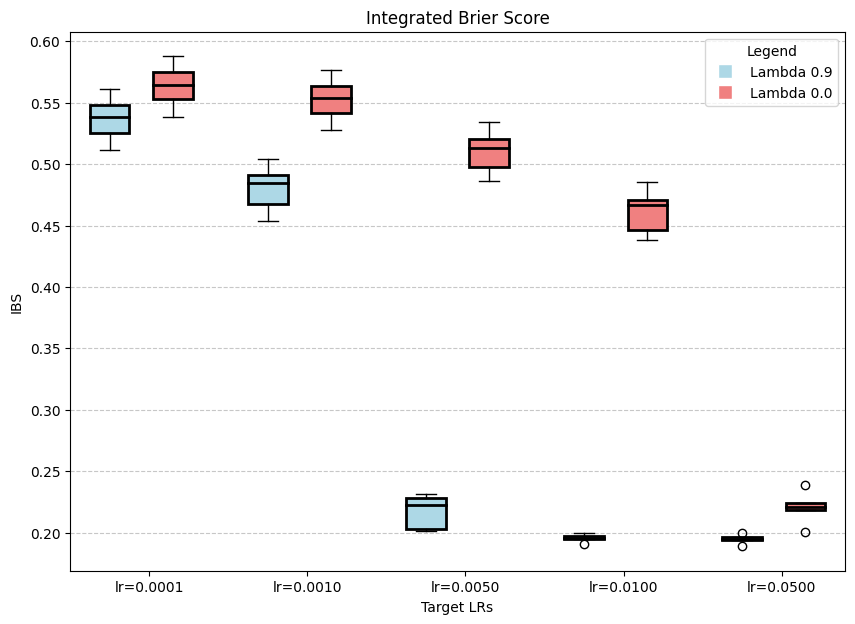

In [33]:
X = bs_1
Y = bs_0

# Create a list of positions for the boxplots
positions = np.arange(1, X.shape[1]*2, step=2)

# Set box colors
boxprops_X = dict(facecolor='lightblue', edgecolor='black', linewidth=2)
boxprops_Y = dict(facecolor='lightcoral', edgecolor='black', linewidth=2)

# Set mean line properties
medianprops = dict(color='black', linewidth=2)

# Set figure size
plt.figure(figsize=(10, 7))

# Plotting boxplots for X
plt.boxplot(X, positions=positions, labels=['' for i in range(len(tgt_lrs))], boxprops=boxprops_X, medianprops=medianprops, patch_artist=True)

# Plotting boxplots for Y
plt.boxplot(Y, positions=positions + 0.8, labels=['' for i in range(len(tgt_lrs))], boxprops=boxprops_Y, medianprops=medianprops, patch_artist=True)

# Create legend
legend_X = plt.Line2D([0], [0], marker='s', color='w', markerfacecolor='lightblue', markersize=10, label='Lambda 0.9')
legend_Y = plt.Line2D([0], [0], marker='s', color='w', markerfacecolor='lightcoral', markersize=10, label='Lambda 0.0')

plt.legend(handles=[legend_X, legend_Y], title='Legend')

# Customize the grid to have only horizontal lines
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Set x-axis labels within boxplots
labels = [f'lr={lr:.4f}' for lr in tgt_lrs]
plt.xticks(positions+.5, labels, ha='center')


plt.xlabel('Target LRs')
plt.ylabel('IBS')
plt.title('Integrated Brier Score')

# Set y-axis limits
# plt.ylim(0.15, .25)

plt.show()


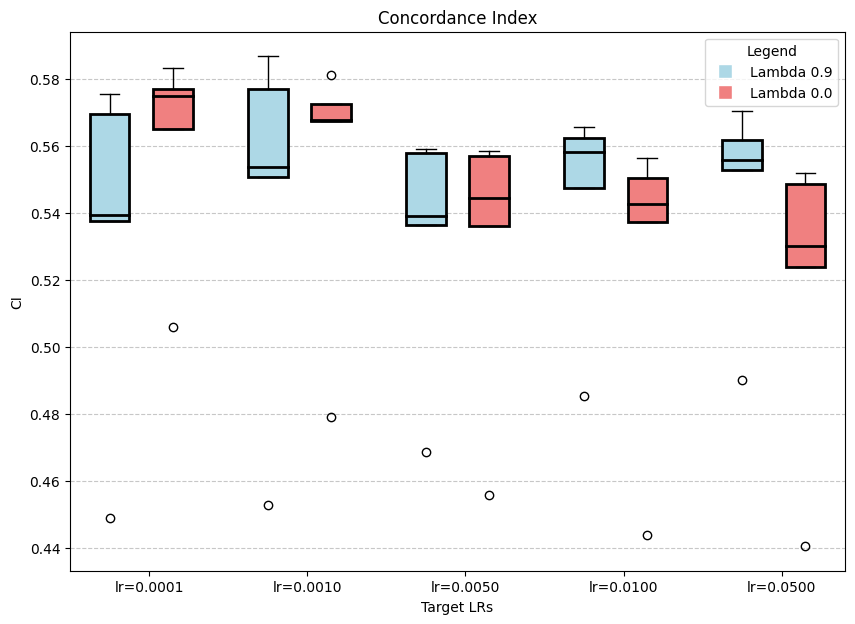

In [34]:
X = ci_1
Y = ci_0

# Create a list of positions for the boxplots
positions = np.arange(1, X.shape[1]*2, step=2)

# Set box colors
boxprops_X = dict(facecolor='lightblue', edgecolor='black', linewidth=2)
boxprops_Y = dict(facecolor='lightcoral', edgecolor='black', linewidth=2)

# Set mean line properties
medianprops = dict(color='black', linewidth=2)

# Set figure size
plt.figure(figsize=(10, 7))

# Plotting boxplots for X
plt.boxplot(X, positions=positions, labels=['' for i in range(len(tgt_lrs))], boxprops=boxprops_X, medianprops=medianprops, patch_artist=True)

# Plotting boxplots for Y
plt.boxplot(Y, positions=positions + 0.8, labels=['' for i in range(len(tgt_lrs))], boxprops=boxprops_Y, medianprops=medianprops, patch_artist=True)

# Create legend
legend_X = plt.Line2D([0], [0], marker='s', color='w', markerfacecolor='lightblue', markersize=10, label='Lambda 0.9')
legend_Y = plt.Line2D([0], [0], marker='s', color='w', markerfacecolor='lightcoral', markersize=10, label='Lambda 0.0')

plt.legend(handles=[legend_X, legend_Y], title='Legend')

# Customize the grid to have only horizontal lines
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Set x-axis labels within boxplots
labels = [f'lr={lr:.4f}' for lr in tgt_lrs]
plt.xticks(positions+.5, labels, ha='center')


plt.xlabel('Target LRs')
plt.ylabel('CI')
plt.title('Concordance Index')

# Set y-axis limits
# plt.ylim(0.6, 0.8)

plt.show()


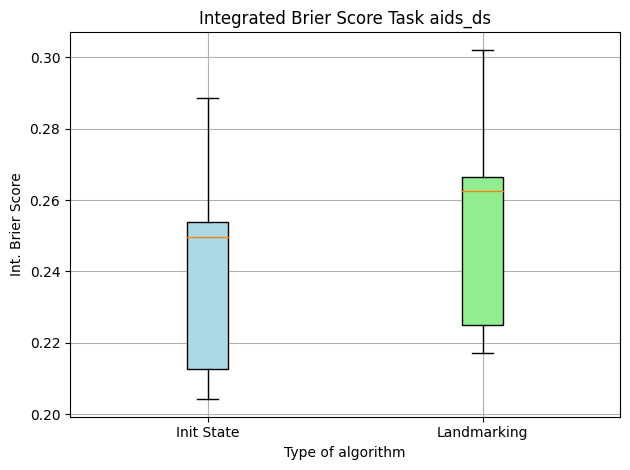

In [10]:

# Create a figure and axis
fig, ax = plt.subplots()

# Set the positions for the boxes
positions = [1, 2]

# Create the boxplots
x = res2_is.reshape(-1)
y = res2_lm.reshape(-1)
boxplot = ax.boxplot([x, y], positions=positions, patch_artist=True)

# Customize the appearance (colors, labels, etc.) as needed
ax.set_xticks(positions)
ax.set_xticklabels(['Init State', 'Landmarking'])
ax.set_xlabel("Type of algorithm")
ax.set_ylabel("Int. Brier Score")
ax.set_title("Integrated Brier Score Task {}".format(task_id))
ax.grid()

# Optionally, fill the boxes with colors
colors = ['lightblue', 'lightgreen']
for patch, color in zip(boxplot['boxes'], colors):
    patch.set_facecolor(color)

# Save the figure as a PDF with tight layout
plt.tight_layout()  # Ensures a tight layout
plt.savefig("../../Figures/Int_brier_score_task_{}.pdf".format(task_id), format="pdf")

plt.show()

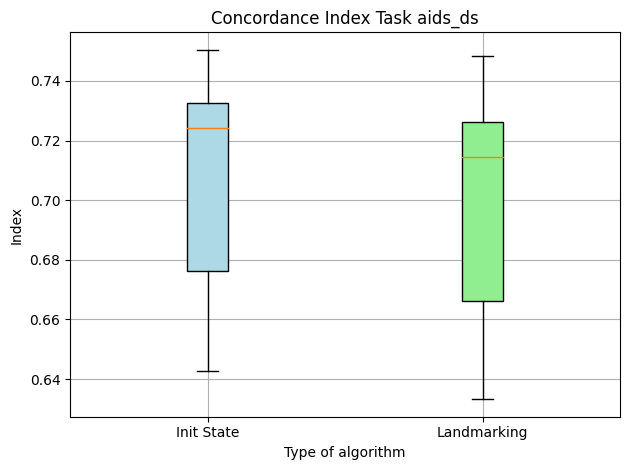

In [11]:

# Create a figure and axis
fig, ax = plt.subplots()

# Set the positions for the boxes
positions = [1, 2]

# Create the boxplots
x = res3_is.reshape(-1)
y = res3_lm.reshape(-1)
boxplot = ax.boxplot([x, y], positions=positions, patch_artist=True)

# Customize the appearance (colors, labels, etc.) as needed
ax.set_xticks(positions)
ax.set_xticklabels(['Init State', 'Landmarking'])
ax.set_xlabel("Type of algorithm")
ax.set_ylabel("Index")
ax.set_title("Concordance Index Task {}".format(task_id))
ax.grid()

# Optionally, fill the boxes with colors
colors = ['lightblue', 'lightgreen']
for patch, color in zip(boxplot['boxes'], colors):
    patch.set_facecolor(color)

# Save the figure as a PDF with tight layout
plt.tight_layout()  # Ensures a tight layout
plt.savefig("../../Figures/conc_idx_task_{}.pdf".format(task_id), format="pdf")

plt.show()


In [5]:
config['target_lr'] = 0.1
config['num_epochs'] = 100
config['learning_rate'] = .01

In [19]:
config['lambda_'] = 0.0

In [20]:
config['target_lr']

0.1

In [21]:
model = DeepLambdaSA(config, seed=2)

train_gen, test_gen = model.get_train_test(test_size=.2)
seqs = test_gen.X
ts = test_gen.ts
cs = test_gen.cs

In [30]:
losses = model.train(train_gen)

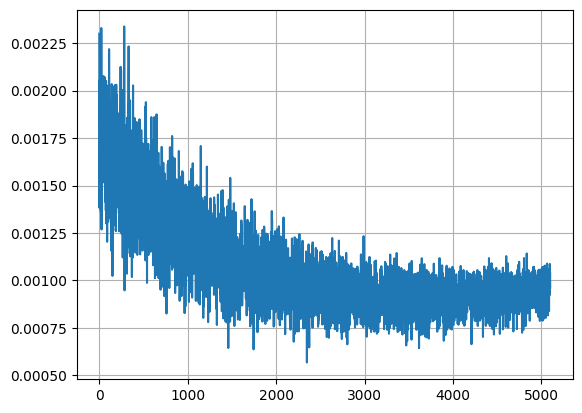

In [31]:
plt.plot(losses)
plt.grid()
plt.show()

In [24]:
surv = model.survival_curve(seqs)
print('IBS ', model.integrated_brier_score(surv[:,0], ts, cs))

IBS  0.27054664


In [25]:
scores = model.scores(seqs)
print('CI: ', concordance_index(scores, ts, cs))

CI:  0.03617869469618378


In [26]:
surv[:,0].shape

(814, 101)

In [27]:
scores = scores.round(2)

In [28]:
ts[~cs]

array([ 22,  24,   8,  99,  40,  16,   1,   4,   6,  34,  25,  21,   1,
        81,  37,  24,  32,  45,  37,  19,  26,  99,  74,  81,  76,  89,
        95,  92,   2,  48,  22, 100,  63,  99,  32,  49,  77,  33,  48,
        12,  26,  99,  25,  29,   8,  26,  62,  13,  80,  87,  14,  21,
         1,  10,   1,  57,  25,  37,  56,   8,  20,  91,  94,  28,   8,
        27,  64,   5,  72,  72,  16,  51,  19,  60,  96,  37, 100,  11,
        33,  17,   4,   3,   5,  58,  21,  98,  57,  97,  56,  87,  11,
        13,  23,  57,  32,  11,  29,  98,  95,   7,  34,   2, 100,   7,
        14,  20,  95,  90,  67,  99,  90,  94,  30,  81,  23,  31,  20,
         8,   7,  10,   7,   2, 100,  42,  93,  80,  95,  21,   2,  30,
        23,  23,  16,  97,  33,  24,  37,  43,  43,  14,   1,  39,  12,
        17,  36,  31,  85,  15,  26,  15,  51,  98,  53,  12,  91,  19,
        93,  30,  26,  97,  16,  29,   9,   1,  84,  98,   6,   2,  60,
        98,   3,   9,   6,  74,   8,  38,  41,  95,  26,  20, 10

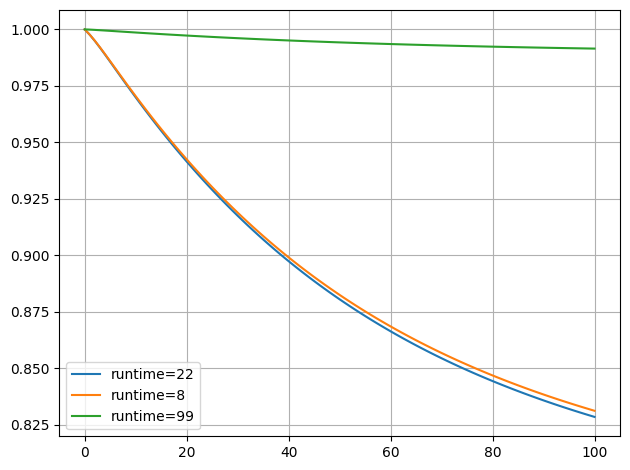

In [29]:
plt.plot(surv[:,0][0], label='runtime=22')
plt.plot(surv[:,0][2], label='runtime=8')
plt.plot(surv[:,0][3], label='runtime=99')
plt.legend()
plt.grid()

plt.tight_layout()  # Ensures a tight layout
plt.savefig("../../Figures/surv_curves_task_{}.pdf".format(task_id), format="pdf")

plt.show()